# Análisis de datos geográfico
## Materia: Sistema de información geográfica
## Docente: Ing. Gonzales Cespedes, Rolando
## Estudiante: Huanca Acebo, Junior Sesario

### 1. Importanción de librerias

In [1]:
import pandas as pd
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

### 2. Lectura CSV (Focos de Calor Bolivia - 2024)

In [2]:
DATA_PATH="/Users/Junior/Downloads/ANÁLISIS DE DATOS/Incendios Forestales/"
FILE_FC_MUNICIPIOS = 'FC-municipios-Bo-2024.csv'

In [3]:
df = pd.read_csv(DATA_PATH + FILE_FC_MUNICIPIOS)

#### 2.1. Comprobación de lectura

In [4]:
df.columns

Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_t31', 'frp', 'daynight', 'type', 'year', 'month', 'day',
       'geometry', 'index_right', 'ID', 'CODSECCION', 'CODIGO', 'COD_DEP',
       'NOM_DEP', 'COD_PROV', 'NOM_PROV', 'NOM_MUN', 'HECTARES'],
      dtype='object')

#### 2.2. Cantidad Focos de Calor

In [5]:
df.shape

(2031628, 29)

### 3. Santa Cruz - 2024 (Focos de Calor)

#### 3.1. Asignar DataFrame

In [6]:
FC_SC = df[df["NOM_DEP"] == "Santa Cruz"]

#### 3.2. Visualizar Total FC

In [7]:
FC_SC.shape

(1556791, 29)

#### 3.3. Cantidad de Focos de Calor por Municipio

In [8]:
municipio_SC = [
    "San Jose de Chiquitos",
    "Concepción",
    "San Ignacio de Velasco",
    "Charagua",
    "Pailón",
    "Robore",
    "Cotoca",
    "El Torno"
]

Fc_x_municipio_SC = FC_SC[FC_SC["NOM_MUN"].isin(municipio_SC)]


Fc_x_municipio_SC = Fc_x_municipio_SC.groupby('NOM_MUN').size().reset_index(name='Cantidad de focos de calor')
Fc_x_municipio_SC = Fc_x_municipio_SC.sort_values(by='Cantidad de focos de calor', ascending=False)
Fc_x_municipio_SC = Fc_x_municipio_SC.rename(columns={"NOM_MUN": "Municipio"})

Fc_x_municipio_SC

,Municipio,Cantidad de focos de calor
1,Concepción,360622
6,San Ignacio de Velasco,261283
7,San Jose de Chiquitos,80514
5,Robore,28271
0,Charagua,9029
4,Pailón,5758
3,El Torno,570
2,Cotoca,417


#### 3.4. Gráfico Mensual (Municipios más afectados SC)

##### 3.4.1. Declaración de un Array de Municipios

In [9]:
fc_municipios_sc = [
    "San Jose de Chiquitos",
    "Concepción",
    "San Ignacio de Velasco"
]

fc_municipios_sc = FC_SC[FC_SC["NOM_MUN"].isin(fc_municipios_sc)]

##### 3.4.2. Agrupación de datos (Mes con Municipios)

In [10]:
Fc_x_mes_SC = (
    fc_municipios_sc
    .groupby(["month", "NOM_MUN"])
    .size()
    .reset_index(name="Cantidad de focos de calor")
)

##### 3.4.3. Agregar columna nombre del mes

In [11]:
meses = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

Fc_x_mes_SC["Mes"] = Fc_x_mes_SC["month"].map(meses)
Fc_x_mes_SC = Fc_x_mes_SC.rename(columns={"NOM_MUN": "Municipio"})

##### 3.4.5. Gráfico Comparativo

In [12]:
fig = px.line(
    Fc_x_mes_SC,
    x="Mes",
    y="Cantidad de focos de calor",
    color="Municipio",
    markers=True,
    title="Distribución mensual de focos de calor por municipio"
)

fig.update_layout(
    width=1200,
    height=850,
    xaxis=dict(dtick=1),
    yaxis=dict(
        tickmode="linear",
        tick0=0,
        dtick=20000
    ),
    legend=dict(
        x=0.01,
        y=0.99,
        xanchor="left",
        yanchor="top"
    )
)

fig.show()

##### 3.4.6. Gráfico del Municipio más afectado (Concepción)

In [13]:
fc_concepcion = Fc_x_mes_SC[Fc_x_mes_SC["Municipio"] == "Concepción"]

fig = px.bar(
    fc_concepcion,
    x="Mes",
    y="Cantidad de focos de calor",
    title="Distribución mensual de focos de calor – Concepción",
    text="Cantidad de focos de calor"
)

fig.update_layout(
    width=1200,
    height=850,
    xaxis=dict(
        dtick=1,
        title="Mes"
    ),
    yaxis=dict(
        tickmode="linear",
        tick0=0,
        dtick=20000,
        title="Cantidad de focos de calor"
    )
)

fig.update_traces(
    textposition="outside"
)

fig.show()


### 4. Beni - 2024 (Focos de Calor)

#### 4.1. Asignar DataFrame

In [14]:
FC_BE = df[df["NOM_DEP"] == "Beni"]

#### 4.2. Visualizar Total FC

In [15]:
FC_BE.shape

(391101, 29)

#### 4.3. Cantidad de Focos de Calor por Mes

In [16]:
Fc_x_mes_BE = (
    FC_BE
    .groupby(["month"])
    .size()
    .reset_index(name="Cantidad de focos de calor")
)

Fc_x_mes_BE["Mes"] = Fc_x_mes_BE["month"].map(meses)

##### 4.3.1. Resultado Tabla

In [17]:
Fc_x_mes_BE_Tabla = Fc_x_mes_BE.sort_values(by='Cantidad de focos de calor', ascending=False)

Fc_x_mes_BE_Tabla

,month,Cantidad de focos de calor,Mes
9,10,118793,Oct
8,9,109908,Sep
7,8,95856,Ago
6,7,38695,Jul
5,6,12842,Jun
10,11,4602,Nov
4,5,3674,May
0,1,2800,Ene
11,12,1865,Dic
3,4,963,Abr


##### 4.3.2. Resultado Gráfico

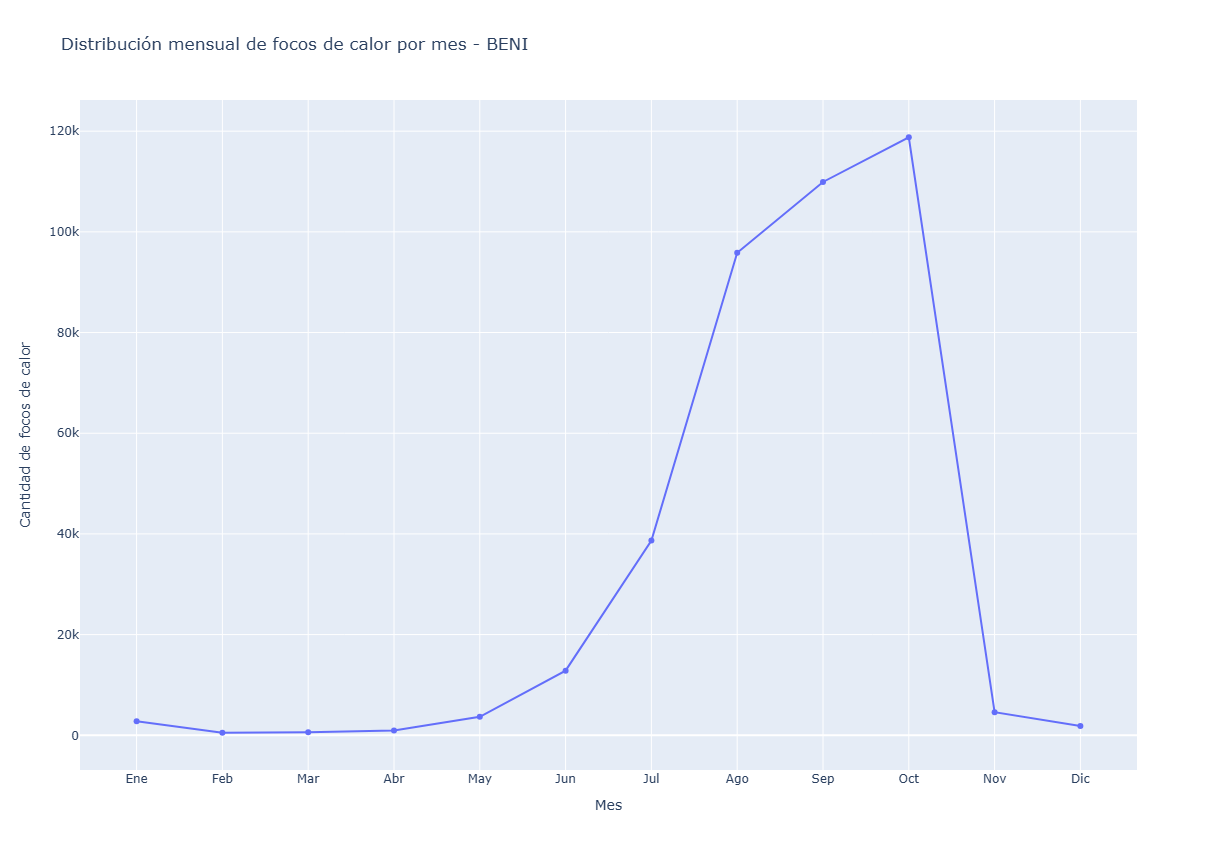

In [18]:
fig = px.line(
    Fc_x_mes_BE,
    x="Mes",
    y="Cantidad de focos de calor",
    markers=True,
    title="Distribución mensual de focos de calor por mes - BENI"
)

fig.update_layout(
    width=1200,
    height=850,
    xaxis=dict(dtick=1),
    yaxis=dict(
        tickmode="linear",
        tick0=0,
        dtick=20000
    )
)

fig.show()

### 5. Cantidad de Focos de Calor de Baures - Beni 2024

In [19]:
FC_Baures = FC_BE[FC_BE["NOM_MUN"]== "Baures"]

In [20]:
FC_Baures.shape

(41731, 29)